In [5]:
from bs4 import BeautifulSoup
import re
url = "Thermodynamics of Folding2.html"
page = open(url)
soup = BeautifulSoup(page.read())
table = soup.find("table")
rows = table.find_all("tr")[1:]
gibs_to_kt = 1.689

In [14]:
from collections import defaultdict
nucl_pos = defaultdict(lambda: 0)
for_pos = {}
back_pos = {}
for row in rows:
    tds = row.find_all(["td",'th'])
    # print(tds)
    if tds[2].find("sup"):
        # print(tds)
        words = re.split(' |-', tds[2].text)
        print(words)
        energy = float(tds[1].text)*-1*gibs_to_kt
        nucl_pos[words[-3]] = energy
        for_pos[words[-3]] = energy - (10.1*(int(words[-3])*.59))
        nucl_pos[words[-1]] = energy
        back_pos[words[-1]] = energy
        # print(words)
    # if tds[0].text == "Helix":
    #     print(tds)
positions = list(for_pos.keys())
energies = list(for_pos.values())
acc_energies = [energies[0]]
for energy in energies[1:]:
    acc_energies.append(energy+acc_energies[-1])
print(acc_energies)

['External', 'closing', 'pair', 'is', 'g', '1', 'c', '59']
['External', 'closing', 'pair', 'is', 'g', '2', 'c', '58']
['External', 'closing', 'pair', 'is', 'g', '3', 'c', '57']
['External', 'closing', 'pair', 'is', 'u', '4', 'a', '56']
['External', 'closing', 'pair', 'is', 'u', '6', 'a', '55']
['External', 'closing', 'pair', 'is', 'c', '7', 'g', '54']
['External', 'closing', 'pair', 'is', 'u', '8', 'g', '53']
['External', 'closing', 'pair', 'is', 'c', '9', 'g', '52']
['External', 'closing', 'pair', 'is', 'u', '10', 'a', '51']
['External', 'closing', 'pair', 'is', 'g', '11', 'u', '50']
['External', 'closing', 'pair', 'is', 'g', '12', 'c', '49']
['External', 'closing', 'pair', 'is', 'u', '13', 'a', '48']
['External', 'closing', 'pair', 'is', 'u', '14', 'a', '47']
['External', 'closing', 'pair', 'is', 'a', '15', 'u', '46']
['External', 'closing', 'pair', 'is', 'g', '16', 'c', '45']
['External', 'closing', 'pair', 'is', 'c', '18', 'g', '44']
['External', 'closing', 'pair', 'is', 'c', '19',

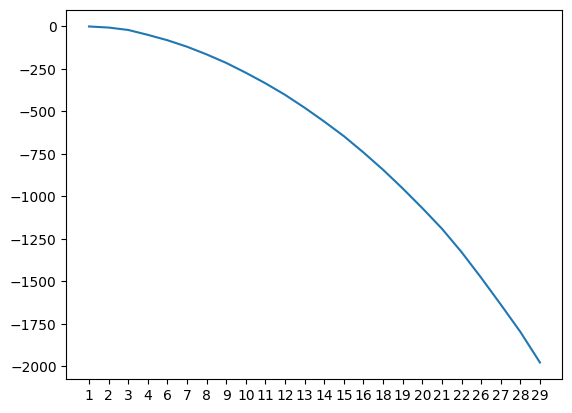

In [15]:
import matplotlib.pyplot as plt
plt.plot(positions, acc_energies)

In [ ]:
test = []
for i in range(1, 209):
    test.append(nucl_pos[str(i)])
%store test
print(test)
print(len(test))

In [37]:
import requests
headers = {
    'Access-Control-Allow-Origin': '*',
    'Access-Control-Allow-Methods': 'GET',
    'Access-Control-Allow-Headers': 'Content-Type',
    'Access-Control-Max-Age': '3600',
    'User-Agent': 'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:52.0) Gecko/20100101 Firefox/52.0'
    }
structure_id = 1
url = "http://www.unafold.org/results/13/24Jul29-13-33-11/"
url = "http://www.unafold.org/results/13/24Jul29-13-40-10/"
analysis_id = url.split('/')[-2]
print(analysis_id)

vienna_URL = f"http://www.unafold.org/cgi-bin/ct2b.cgi?ID={analysis_id}&COUNT={structure_id}"
print(vienna_URL)
# print(vienna_URL)
req = requests.get(vienna_URL, headers)
seq, dot_bracket, _ = req.text.split('\n')
dot_bracket = dot_bracket.split('\t')[0]
soup = BeautifulSoup(req.content, 'html.parser')
print(soup)

24Jul29-13-40-10
http://www.unafold.org/cgi-bin/ct2b.cgi?ID=24Jul29-13-40-10&COUNT=1
CGCUUCAUAUAAUCCUAAUGAUAUGGUUUGGGAGUUUCUACCAAGAGCCUUAAACUCUUGAUUAUGAAGUCUGUCGCUUUAUCCGAAAUUUUAUAAAGAGAAGACUCAUGAAUUACUUUGACCUGCCGA
.((.((((.........))))...((((..((.........((((((.......)))))).((((((.((((.((.((((((..........)))))).))))))))))))....))..)))).))...	(-18.97)



In [39]:
# "http://www.unafold.org/cgi-bin/det.cgi?ID=24Jul29-13-33-11&COUNT=1"
# "http://www.unafold.org/results/13/24Jul29-13-33-11/24Jul29-13-33-11_1.full_det.html"
# energy_URL = f"http://www.unafold.org/cgi-bin/det.cgi?ID={analysis_id}-11&COUNT={structure_id}"
energy_URL = f"http://www.unafold.org/results/13/{analysis_id}/{analysis_id}_{structure_id}.full_det.html"
print(energy_URL)
req = requests.get(energy_URL, headers)
# ID: 24Jul29-13-45-54
# COUNT: 1
soup = BeautifulSoup(req.content, 'html.parser')
print(soup)


http://www.unafold.org/results/13/24Jul29-13-40-10/24Jul29-13-40-10_1.full_det.html
<!DOCTYPE html>

<html lang="en">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width, initial-scale=1, shrink-to-fit=no" name="viewport"/>
<meta content="" name="description"/>
<title>Thermodynamics of Folding</title>
<!-- Bootstrap core CSS -->
<link href="/assets/bootstrap/css/bootstrap.min.css" rel="stylesheet"/>
<link href="/assets/css/style.css" rel="stylesheet"/>
<script>window.jQuery || document.write('<script src="/assets/js/vendor/jquery.min.js"><\/script>')</script>
<script type="text/javascript"> 
    $(document).ready(function(){ 
        
        // **** template redirect option code starts here
        var refresh_time = 0;
        var refresh_url = "";
        
        if (refresh_time > 0 && refresh_url != "") {
        	setTimeout(redir, refresh_time);
        }
        // **** and ends here
    }); 
    
    // **** template redirect option code starts here
    function r